<a href="https://colab.research.google.com/github/FinancialWisdomAI/FinancialWisdomSimulator/blob/main/financial_wisdom_simulator_basic_single_cell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Asset database loaded.

                         Asset  MeanReturn  StdDev
0           S&P 500 Index Fund      0.1185   0.194
1   60/40 Stock-Bond Portfolio      0.0800   0.120
2       Conservative Portfolio      0.0500   0.060
3                 US Large Cap      0.1185   0.194
4                 US Small Cap      0.1200   0.250
5         International Stocks      0.0850   0.170
6                        Bonds      0.0500   0.070
7                         Cash      0.0250   0.010
8                        REITs      0.1000   0.200
9                Growth Stocks      0.1300   0.230
10                Value Stocks      0.1100   0.180
11              Treasury Bonds      0.0400   0.050
12                        Gold      0.0600   0.150
 Financial Wisdom Monte Carlo Simulator

What is your financial goal? retire
What is your goal amount ($)? 600000
How many years until you need the money? 20
Initial investment amount ($): 100000
Monthly contribution ($): 200

Portfolio Construction Method
1 - 

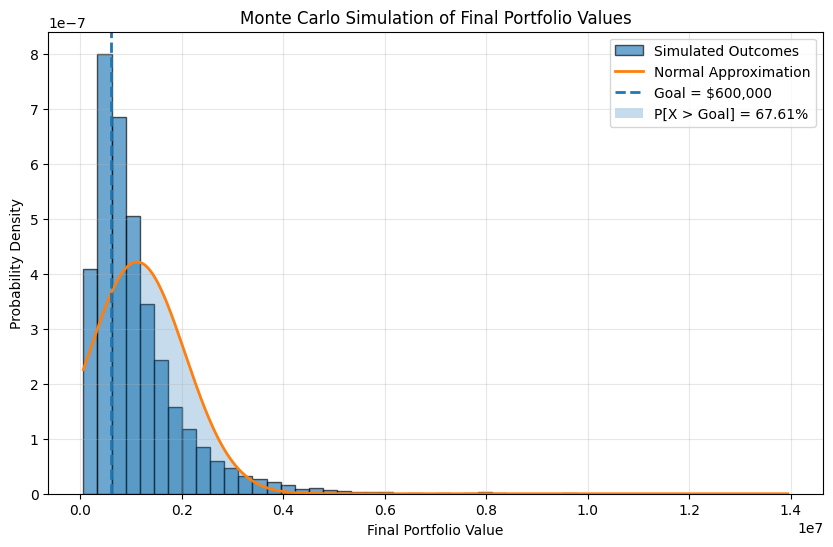

In [3]:
# ============================================================
# FINANCIAL WISDOM MONTE CARLO SIMULATOR
# Basic single-cell notebook version for Colab debugging
# ============================================================


# --------------------------- config.py ---------------------------
"""Configuration values for the Financial Wisdom Simulator."""

DEFAULT_NUM_SIMULATIONS = 10_000
RANDOM_SEED = None
MIN_ANNUAL_RETURN = -0.99

# --------------------------- user_inputs.py ---------------------------
"""User input and validation helpers."""
import sys


def _quit_if_requested(response: str) -> None:
    if response.lower() in ["q", "quit", "exit"]:
        print("\nExiting Financial Wisdom Simulator.")
        sys.exit()


def get_money(prompt: str) -> float:
    while True:
        response = input(prompt).strip()
        _quit_if_requested(response)
        try:
            return float(response.replace('$', '').replace(',', ''))
        except ValueError:
            print("Please enter a valid dollar amount. Examples: 1000, 1,000, $1,000. Type 'q' to quit.")


def get_integer(prompt: str) -> int:
    while True:
        response = input(prompt).strip()
        _quit_if_requested(response)
        try:
            return int(response.replace('$', '').replace(',', ''))
        except ValueError:
            print("Please enter a whole number. Examples: 10000 or 10,000. Type 'q' to quit.")


def get_yes_no(prompt: str) -> str:
    while True:
        response = input(prompt).strip().lower()
        _quit_if_requested(response)
        if response in ["yes", "y"]:
            return "Yes"
        if response in ["no", "n"]:
            return "No"
        print("Please answer Yes or No. Examples: yes, y, no, n. Type 'q' to quit.")


def collect_user_plan() -> dict:
    print("======================================")
    print(" Financial Wisdom Monte Carlo Simulator")
    print("======================================\n")

    plan = {
        "goal_name": input("What is your financial goal? "),
        "goal_amount": get_money("What is your goal amount ($)? "),
        "years": get_integer("How many years until you need the money? "),
        "initial_balance": get_money("Initial investment amount ($): "),
        "monthly_contribution": get_money("Monthly contribution ($): "),
    }

    if plan["goal_amount"] <= 0:
        print("Warning: goal amount should be positive.")
    if plan["years"] <= 0:
        print("Warning: time horizon should be positive.")
    if plan["initial_balance"] < 0 or plan["monthly_contribution"] < 0:
        print("Warning: balances and contributions should not be negative.")

    return plan

# --------------------------- portfolio.py ---------------------------
"""Asset database and portfolio construction."""
import pandas as pd

ASSET_DATA = [
    {"Asset": "S&P 500 Index Fund", "MeanReturn": 0.1185, "StdDev": 0.194},
    {"Asset": "60/40 Stock-Bond Portfolio", "MeanReturn": 0.0800, "StdDev": 0.120},
    {"Asset": "Conservative Portfolio", "MeanReturn": 0.0500, "StdDev": 0.060},
    {"Asset": "US Large Cap", "MeanReturn": 0.1185, "StdDev": 0.194},
    {"Asset": "US Small Cap", "MeanReturn": 0.1200, "StdDev": 0.250},
    {"Asset": "International Stocks", "MeanReturn": 0.0850, "StdDev": 0.170},
    {"Asset": "Bonds", "MeanReturn": 0.0500, "StdDev": 0.070},
    {"Asset": "Cash", "MeanReturn": 0.0250, "StdDev": 0.010},
    {"Asset": "REITs", "MeanReturn": 0.1000, "StdDev": 0.200},
    {"Asset": "Growth Stocks", "MeanReturn": 0.1300, "StdDev": 0.230},
    {"Asset": "Value Stocks", "MeanReturn": 0.1100, "StdDev": 0.180},
    {"Asset": "Treasury Bonds", "MeanReturn": 0.0400, "StdDev": 0.050},
    {"Asset": "Gold", "MeanReturn": 0.0600, "StdDev": 0.150},
]


def load_asset_database() -> pd.DataFrame:
    return pd.DataFrame(ASSET_DATA)


def choose_portfolio(asset_db: pd.DataFrame) -> dict:
    print("\nPortfolio Construction Method")
    print("1 - Predefined Portfolio")
    print("2 - Build Custom Portfolio")
    portfolio_method = get_integer("Choose method (1-2): ")

    if portfolio_method == 1:
        print("\nPredefined Portfolios")
        print("1 - S&P 500 Index Fund")
        print("2 - 60/40 Stock-Bond Portfolio")
        print("3 - Conservative Portfolio")
        portfolio_choice = get_integer("Choose portfolio (1-3): ")
        row = asset_db.iloc[portfolio_choice - 1]
        return {
            "portfolio_method": portfolio_method,
            "portfolio_choice": portfolio_choice,
            "portfolio_name": row["Asset"],
            "mean_return": float(row["MeanReturn"]),
            "std_return": float(row["StdDev"]),
            "weights": None,
        }

    print("\nAvailable Assets")
    print(asset_db)
    weights = []
    for _, row in asset_db.iterrows():
        pct = get_integer(f"Allocation to {row['Asset']} (%): ")
        weights.append(pct / 100)

    total_weight = sum(weights)
    if abs(total_weight - 1.0) > 1e-6:
        print(f"Warning: allocations sum to {total_weight:.2%}, not 100%.")

    mean_return = sum(weights[i] * asset_db.iloc[i]["MeanReturn"] for i in range(len(weights)))
    # Simple weighted volatility approximation retained from Version 1.
    std_return = sum(weights[i] * asset_db.iloc[i]["StdDev"] for i in range(len(weights)))

    return {
        "portfolio_method": portfolio_method,
        "portfolio_choice": None,
        "portfolio_name": "Custom Portfolio",
        "mean_return": float(mean_return),
        "std_return": float(std_return),
        "weights": weights,
    }


def display_portfolio_statistics(portfolio: dict) -> None:
    print("\n======================================")
    print(" Portfolio Statistics")
    print("======================================")
    print(f"Portfolio: {portfolio['portfolio_name']}")
    print(f"Expected Return: {portfolio['mean_return']:.2%}")
    print(f"Estimated Risk : {portfolio['std_return']:.2%}")

# --------------------------- monte_carlo.py ---------------------------
"""Monte Carlo simulation engine."""
import numpy as np


def simulate_portfolio(initial_balance: float, monthly_contribution: float, years: int,
                       mean_return: float, std_return: float, num_simulations: int,
                       min_annual_return: float = -0.99, random_seed=None) -> np.ndarray:
    rng = np.random.default_rng(random_seed)
    final_values = []

    for _ in range(num_simulations):
        balance = initial_balance
        for _ in range(years):
            annual_return = max(rng.normal(mean_return, std_return), min_annual_return)
            monthly_return = (1 + annual_return) ** (1 / 12) - 1
            if abs(monthly_return) < 1e-12:
                yearly_contribution_value = monthly_contribution * 12
            else:
                yearly_contribution_value = monthly_contribution * (((1 + monthly_return) ** 12 - 1) / monthly_return)
            balance = balance * (1 + annual_return) + yearly_contribution_value
        final_values.append(balance)

    return np.array(final_values)

# --------------------------- statistics.py ---------------------------
"""Simulation summary statistics."""
import numpy as np


def summarize_results(final_values, goal: float) -> dict:
    return {
        "mean_final": float(np.mean(final_values)),
        "median_final": float(np.median(final_values)),
        "std_final": float(np.std(final_values)),
        "prob_success": float(np.mean(final_values > goal)),
        "p10": float(np.percentile(final_values, 10)),
        "p25": float(np.percentile(final_values, 25)),
        "p75": float(np.percentile(final_values, 75)),
        "p90": float(np.percentile(final_values, 90)),
    }

# --------------------------- graphics.py ---------------------------
"""Charts and visualizations."""
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def plot_final_value_histogram(final_values, goal: float, output_path=None) -> None:
    mean_final = np.mean(final_values)
    std_final = np.std(final_values)
    prob_success = np.mean(final_values > goal)

    plt.figure(figsize=(10, 6))
    plt.hist(final_values, bins=50, density=True, edgecolor="black", alpha=0.65, label="Simulated Outcomes")
    x = np.linspace(min(final_values), max(final_values), 500)
    normal_curve = norm.pdf(x, mean_final, std_final)
    plt.plot(x, normal_curve, linewidth=2, label="Normal Approximation")
    plt.axvline(goal, linestyle="--", linewidth=2, label=f"Goal = ${goal:,.0f}")
    plt.fill_between(x, normal_curve, where=(x > goal), alpha=0.25, label=f"P[X > Goal] = {prob_success:.2%}")
    plt.xlabel("Final Portfolio Value")
    plt.ylabel("Probability Density")
    plt.title("Monte Carlo Simulation of Final Portfolio Values")
    plt.legend()
    plt.grid(alpha=0.3)
    if output_path:
        plt.savefig(output_path, bbox_inches="tight", dpi=200)
    plt.show()

# --------------------------- wisdom_engine.py ---------------------------
"""Financial Wisdom behavioral observations and scores."""

RESPONSE_LIBRARY = {
    "no_emergency_fund": ("Responsibility", "Financial Wisdom encourages preparation before risk-taking.", "Your plan does not currently include an emergency fund."),
    "high_interest_debt": ("Responsibility", "Costly debt works against long-term progress.", "Your plan includes high-interest debt."),
    "no_monthly_contribution": ("Responsibility", "Progress usually requires regular action.", "Your plan does not include a monthly contribution."),
    "aggressive_short_horizon": ("Patience", "Short horizons leave less time to recover from market declines.", "An aggressive portfolio over a short horizon may expose the goal to unnecessary risk."),
    "low_risk_high_goal": ("Modesty", "A very cautious portfolio may not support an ambitious goal.", "The plan may require either more saving, more time, or a different portfolio."),
    "high_risk_low_tolerance": ("Humility", "The portfolio should match the investor's ability to endure volatility.", "The selected portfolio may be too aggressive for the stated risk tolerance."),
}


def build_observations(plan: dict, portfolio: dict, summary: dict) -> list[dict]:
    keys = []
    if plan.get("emergency_fund") == "No":
        keys.append("no_emergency_fund")
    if plan.get("high_interest_debt") == "Yes":
        keys.append("high_interest_debt")
    if plan.get("monthly_contribution", 0) <= 0:
        keys.append("no_monthly_contribution")
    if portfolio.get("std_return", 0) > 0.15 and plan.get("years", 0) <= 5:
        keys.append("aggressive_short_horizon")
    if portfolio.get("std_return", 0) > 0.15 and plan.get("risk_tolerance") == 1:
        keys.append("high_risk_low_tolerance")
    if portfolio.get("std_return", 0) < 0.08 and summary.get("prob_success", 0) < 0.60:
        keys.append("low_risk_high_goal")

    observations = []
    for key in keys:
        category, principle, message = RESPONSE_LIBRARY[key]
        observations.append({"key": key, "category": category, "principle": principle, "message": message})
    return observations


def score_plan(plan: dict, portfolio: dict) -> dict:
    scores = {"Responsibility": 5, "Humility": 5, "Modesty": 5, "Patience": 5, "Self-Control": 5}
    if plan.get("emergency_fund") == "No":
        scores["Responsibility"] -= 2
    if plan.get("high_interest_debt") == "Yes":
        scores["Responsibility"] -= 2
    if plan.get("monthly_contribution", 0) <= 0:
        scores["Responsibility"] -= 1
    if portfolio.get("std_return", 0) > 0.15 and plan.get("risk_tolerance") == 1:
        scores["Humility"] -= 2
    if portfolio.get("std_return", 0) > 0.15 and plan.get("years", 0) <= 5:
        scores["Patience"] -= 1
    return {k: max(0, v) for k, v in scores.items()}

# --------------------------- reporting.py ---------------------------
"""Console report functions."""
import numpy as np


def display_results(plan: dict, portfolio: dict, summary: dict, final_values) -> None:
    print("\n======================================")
    print(" Financial Wisdom Simulation Results")
    print("======================================")
    print(f"Goal: {plan['goal_name']}")
    print(f"Portfolio: {portfolio['portfolio_name']}")
    print(f"\nMean Final Value: ${summary['mean_final']:,.2f}")
    print(f"Median Final Value: ${summary['median_final']:,.2f}")
    print(f"Standard Deviation: ${summary['std_final']:,.2f}")
    print(f"Probability of Reaching Goal: {summary['prob_success']:.2%}")

    if summary['prob_success'] >= 0.90:
        print("Excellent. Your goal appears highly achievable.")

    elif summary['prob_success'] >= 0.70:
        print("Your plan has a good chance of success, but uncertainty remains.")

    elif summary['prob_success'] >= 0.50:
        print("Your plan has only a moderate chance of success.")
        print("Consider increasing contributions or extending the time horizon.")

    else:
        print("Your goal currently has a low probability of success.")
        print("Significant changes may be needed.")


    print("\nSelected Percentiles")
    for key in ["p10", "p25", "p75", "p90"]:
        print(f"{key.upper()}: ${summary[key]:,.2f}")

    for target in [plan['goal_amount'], 1.25 * plan['goal_amount'], 1.50 * plan['goal_amount']]:
        probability = np.mean(final_values > target)
        print(f"P[X > ${target:,.0f}] = {probability:.2%}")


def display_wisdom_report(observations: list[dict], scores: dict) -> None:
    print("\n======================================")
    print(" Financial Wisdom Observations")
    print("======================================")
    if not observations:
        print("No major behavioral warnings were detected.")
        print("Your plan has a moderate chance of success, but there is still meaningful uncertainty.")
        print("Consider testing a slightly higher monthly contribution or a more conservative goal date.")
    for obs in observations:
        print(f"\n{obs['category']}: {obs['principle']}")
        print(obs['message'])

    print("\n======================================")
    print(" Financial Wisdom Scores")
    print("======================================")
    for category, score in scores.items():
        print(f"{category}: {score}/5")

# --------------------------- future_models.py ---------------------------
"""Placeholder for future historical, bootstrap, and regime-switching models."""


def historical_bootstrap_returns():
    raise NotImplementedError("Historical bootstrap model will be added in a later version.")


"""Placeholder for future retirement-specific simulations."""


def retirement_projection():
    raise NotImplementedError("Retirement planning module will be added in a later version.")

# --------------------------- main.py ---------------------------
def main() -> None:
    asset_db = load_asset_database()
    print("\nAsset database loaded.\n")
    print(asset_db)

    plan = collect_user_plan()
    portfolio = choose_portfolio(asset_db)
    display_portfolio_statistics(portfolio)

    print("\nRisk Tolerance")
    print("1 - Low")
    print("2 - Moderate")
    print("3 - High")
    plan["risk_tolerance"] = get_integer("Choose risk tolerance (1-3): ")
    plan["emergency_fund"] = get_yes_no("\nDo you currently maintain an emergency fund? (yes/no): ")
    plan["high_interest_debt"] = get_yes_no("Do you currently have high-interest debt? (yes/no): ")
    plan["num_simulations"] = get_integer(f"\nNumber of Monte Carlo simulations (e.g., {DEFAULT_NUM_SIMULATIONS}): ")

    final_values = simulate_portfolio(
        initial_balance=plan["initial_balance"],
        monthly_contribution=plan["monthly_contribution"],
        years=plan["years"],
        mean_return=portfolio["mean_return"],
        std_return=portfolio["std_return"],
        num_simulations=plan["num_simulations"],
        min_annual_return=MIN_ANNUAL_RETURN,
        random_seed=RANDOM_SEED,
    )

    summary = summarize_results(final_values, plan["goal_amount"])
    display_results(plan, portfolio, summary, final_values)
    observations = build_observations(plan, portfolio, summary)
    scores = score_plan(plan, portfolio)
    display_wisdom_report(observations, scores)
    plot_final_value_histogram(final_values, plan["goal_amount"])

# Run the simulator
main()
